In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import mplniw.utils as ut
import cmocean

In [2]:
root_dir = '/Users/zcasparcohen/codes/NIW/data/'
ds = xr.open_dataset(root_dir+'niskine_mooring_500m.nc')
grid = xr.open_dataset(root_dir+'niskine_mooring_grid_500m.nc')

topo = xr.open_dataset('/Users/zcasparcohen/Downloads/ETOPO_2022_v1_30s_N90W180_bed.nc').z.sel(lon=slice(-30,-15.3),lat=slice(55,64.8))
topo = topo.isel(lon=slice(0,None,1),lat=slice(0,None,1))

N2=xr.open_dataarray(root_dir+'roms_stratification.nc')
N2 = N2.where(N2>=0)

In [3]:
fc = ut.coriolis(grid.lat_rho)
H = -topo.sel(lat=grid.lat_rho.mean('xi_rho'),lon=grid.lon_rho.mean('eta_rho'),method='nearest')
g=9.81

In [4]:
H = H.rename({'eta_rho':'lat','xi_rho':'lon'})

/var/folders/vl/tj6snrv54zd212pkvk5g_l140000gn/T/ipykernel_2911/1670888842.py:1: UserWarning: rename 'eta_rho' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  H = H.rename({'eta_rho':'lat','xi_rho':'lon'})
/var/folders/vl/tj6snrv54zd212pkvk5g_l140000gn/T/ipykernel_2911/1670888842.py:1: UserWarning: rename 'xi_rho' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  H = H.rename({'eta_rho':'lat','xi_rho':'lon'})


In [5]:
N = np.sqrt(N2)

In [6]:
f = fc.mean('xi_rho').rename({'eta_rho':'lat'})

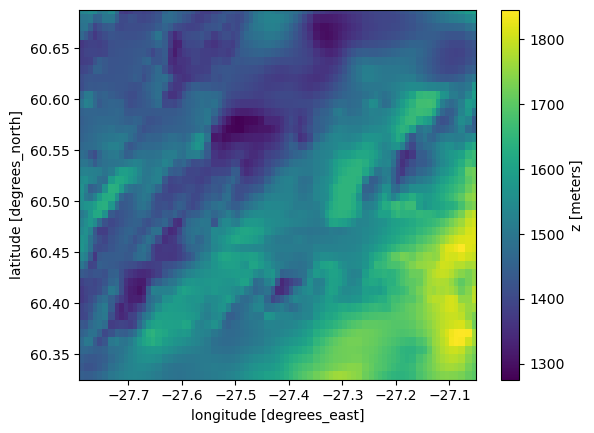

In [7]:
H.plot()

In [15]:
#Barotropic Rossby radius deformation scale
Lr = np.sqrt(g*H)/f
#Baroclinic Rossby radius deformation scale
n = 1
Lr_bc = N*H/(n*np.pi*f)

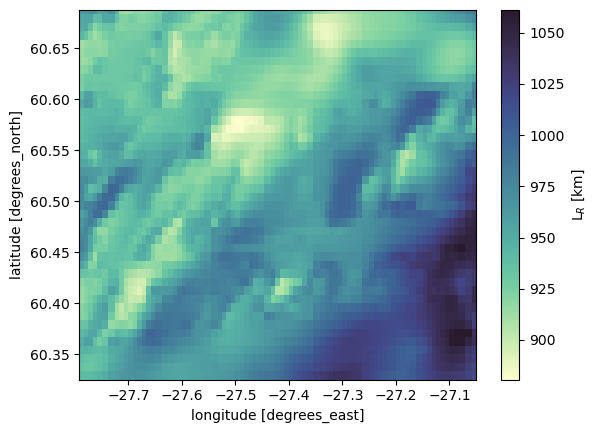

In [9]:
(Lr).plot(cmap=cmocean.cm.deep,cbar_kwargs={'label':r'L$_R$ [km]'})


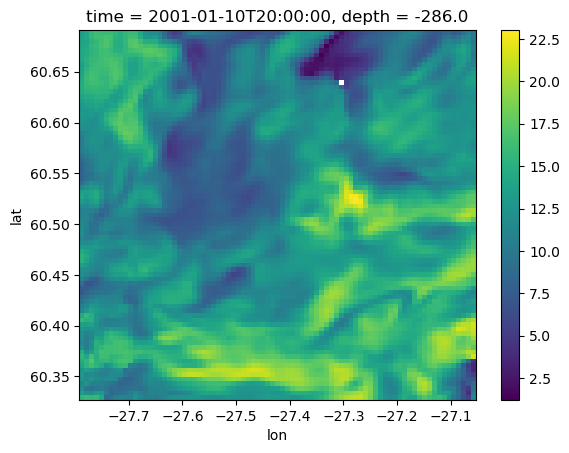

In [10]:
Lr_bc.isel(time=100,depth=30).plot()

In [16]:
# Horizontal IW wavelength
lambda_v = np.arange(100,1000,500)
omega = 1.01*f
lambda_h = xr.concat([l*N/np.sqrt(omega**2-f**2) for l in lambda_v],dim='lv')

In [18]:
lambda_h = lambda_h.assign_coords({'lv':lambda_v})

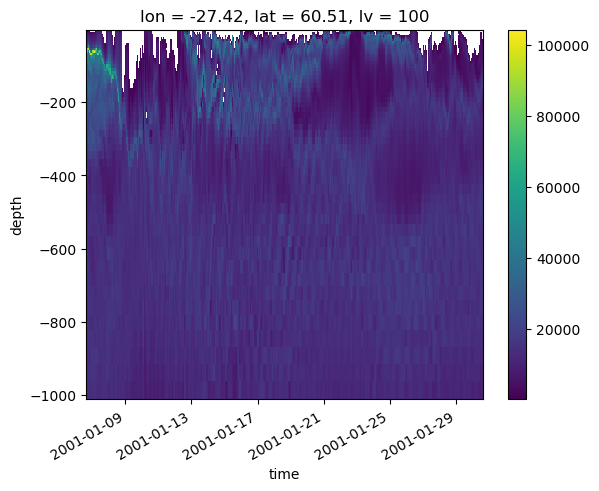

In [19]:
lambda_h.sel(lat=N.lat.median(),lon=N.lon.median(),lv=100,method='nearest').plot(x='time')

In [21]:
Lr_bc = xr.concat([N*H/(n*np.pi*f) for n in np.arange(1,4)],dim='mode').assign_coords({'mode':np.arange(1,4)})

In [22]:
xr.Dataset({'l_IW':lambda_h,'Lr_bc':Lr_bc,'Lr':Lr}).to_netcdf(root_dir+'roms_scales.nc')

In [23]:
N2

<xarray.DataArray 'N2' (lat: 81, lon: 81, time: 576, depth: 53)>
array([[[[7.26142613e-07, 3.60400518e-06, 5.21019954e-06, ...,
          4.36318205e-06, 4.34771243e-06, 4.16800718e-06],
         [4.27437812e-07, 2.72170685e-06, 3.99249543e-06, ...,
          4.26654292e-06, 4.25136318e-06, 3.71789000e-06],
         [2.26487838e-07, 2.04849742e-06, 3.03046141e-06, ...,
          4.27124290e-06, 4.19857328e-06, 3.48276812e-06],
         ...,
         [           nan,            nan,            nan, ...,
          4.25248998e-06, 3.93043955e-06, 4.06220733e-06],
         [           nan,            nan,            nan, ...,
          3.45893081e-06, 4.26016324e-06, 3.81834525e-06],
         [           nan,            nan,            nan, ...,
          3.62459653e-06, 3.83763105e-06, 3.88323449e-06]],

        [[6.61017098e-07, 3.50635442e-06, 5.22041592e-06, ...,
          4.55171496e-06, 4.45086713e-06, 4.15142350e-06],
         [3.78372863e-07, 2.62735936e-06, 3.91690976e-06, ...,
          4.40659745e-06, 4.24127190e-06, 3.57615742e-06],
         [1.02468807e-07, 1.78121053e-06, 2.76130754e-06, ...,
          4.25245307e-06, 4.08523247e-06, 3.44215480e-06],
...
         [           nan,            nan,            nan, ...,
          4.29371937e-06, 3.08884205e-06, 2.60357830e-06],
         [           nan,            nan,            nan, ...,
          3.85559573e-06, 3.09464799e-06, 2.96066487e-06],
         [           nan,            nan,            nan, ...,
          3.37950906e-06, 3.25539537e-06, 3.10088111e-06]],

        [[5.06150326e-06, 7.83607471e-06, 8.49737707e-06, ...,
          6.69557029e-06, 9.36126304e-06, 2.59072626e-06],
         [3.78632756e-06, 6.25245892e-06, 6.64475419e-06, ...,
          6.77579004e-06, 9.00324208e-06, 2.40504001e-06],
         [3.35866569e-06, 5.63419637e-06, 5.77891863e-06, ...,
          4.85676499e-06, 8.10988074e-06, 6.05530964e-06],
         ...,
         [           nan,            nan,            nan, ...,
          4.46288791e-06, 3.15747338e-06, 2.67796442e-06],
         [           nan,            nan,            nan, ...,
          4.33047240e-06, 3.09138240e-06, 2.78012821e-06],
         [           nan,            nan,            nan, ...,
          3.80426336e-06, 3.18300831e-06, 3.16331439e-06]]]])
Coordinates:
  * time     (time) datetime64[ns] 2001-01-06T16:00:00 ... 2001-01-30T15:00:00
  * lon      (lon) float64 -27.79 -27.78 -27.77 -27.76 ... -27.08 -27.07 -27.06
  * lat      (lat) float64 60.33 60.33 60.34 60.34 ... 60.68 60.68 60.68 60.69
  * depth    (depth) float64 -3.5 -7.0 -11.0 -15.5 ... -890.5 -938.0 -987.0